In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [8]:
dataset_list = ["ARC_Challenge", "CommonSenseQA", "MMLU", "OpenBookQA"]
model_list = [
    "EleutherAI/pythia-410m",
    "EleutherAI/pythia-1b",
    "EleutherAI/pythia-1.4b",
    "openai-community/gpt2",
    "openai-community/gpt2-medium",
    "openai-community/gpt2-large",
    "Qwen/Qwen1.5-0.5B",
    "Qwen/Qwen1.5-1.8B",
    "Qwen/Qwen1.5-4B",
    "meta-llama/Llama-3.2-1B",
    "meta-llama/Llama-3.2-3B",
  ]

In [ ]:
def cal_factors(dataset, model_name_or_path):
    path = f"../../results/data_results/factors/{model_name_or_path}/{dataset}_logit.csv"
    df = pd.read_csv(path)

    df["question"] = df["question_id"].astype("category")
    df["prompt"]   = df["prompt_id"].astype("category")
    model = smf.ols("logit ~ C(question) + C(prompt)", data=df).fit()
    anova_tbl = anova_lm(model)
    factors = ["C(question)", "C(prompt)"]
    anova_factors = anova_tbl.loc[factors, ["sum_sq", "F", "PR(>F)"]].copy()
    resid_ss = anova_tbl.loc["Residual", "sum_sq"]
    anova_factors["prop_of_total_ss"] = anova_factors["sum_sq"] / (anova_factors["sum_sq"].sum() + resid_ss)

    prompt_val   = anova_factors.loc["C(prompt)", "prop_of_total_ss"]
    question_val = anova_factors.loc["C(question)", "prop_of_total_ss"]
    resid_val    = 1 - (prompt_val + question_val)
    return prompt_val, question_val, resid_val

In [10]:
model_name_dict = {
    "EleutherAI/pythia-410m": "Pythia-410M",
    "EleutherAI/pythia-1b": "Pythia-1B",
    "EleutherAI/pythia-1.4b": "Pythia-1.4B",
    "meta-llama/Llama-3.2-1B": "Llama-3.2-1B",
    "meta-llama/Llama-3.2-3B": "Llama-3.2-3B",
    "Qwen/Qwen1.5-4B": "Qwen1.5-4B",
    "Qwen/Qwen1.5-0.5B": "Qwen1.5-0.5B",
    "Qwen/Qwen1.5-1.8B": "Qwen1.5-1.8B",
    "openai-community/gpt2": "GPT2-small",
    "openai-community/gpt2-large": "GPT2-large",
    "openai-community/gpt2-medium": "GPT2-medium",
}

In [ ]:
result_list = []
for dataset in dataset_list:
    for model_name_or_path in model_list:
        prompt_val, question_val, resid_val = cal_factors(dataset, model_name_or_path)
        result_list.append(
            {
                "model": model_name_dict[model_name_or_path],
                "factor": "Prompt Template",
                "value": prompt_val
            }
        )
        result_list.append(
            {
                "model": model_name_dict[model_name_or_path],
                "factor": "Question",
                "value": question_val
            }
        )

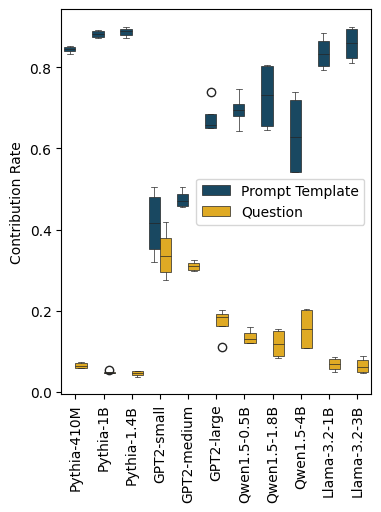

In [ ]:
df = pd.DataFrame(result_list)

fig, ax = plt.subplots(figsize=(4, 5))

palette = ["#0D4C6D", "#FEB705"]
sns.boxplot(data=df, x="model", 
            y="value", 
            hue="factor",
            palette=palette,
            linewidth=0.5
    )
ax.legend_.set_title(None)
plt.xticks(rotation=90)
plt.xlabel(None)
plt.ylabel("Contribution Rate")
plt.show()

save_path = "../../results/figure_results/factor/main_factor.pdf"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
fig.savefig(save_path, bbox_inches="tight")
plt.show()
plt.close(fig)
